In [1]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LogNorm

In [ ]:
file = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7131937/cevns_phonon_00.root")
tree = file["Primary"]
tree2 = file["PhononTracks"]

df = tree.arrays(library="pd")
df2 = tree2.arrays(library="pd")

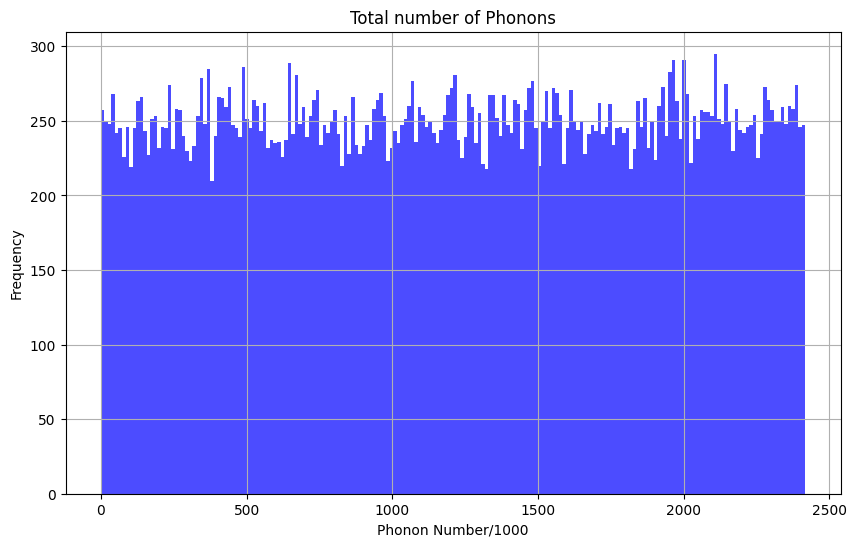

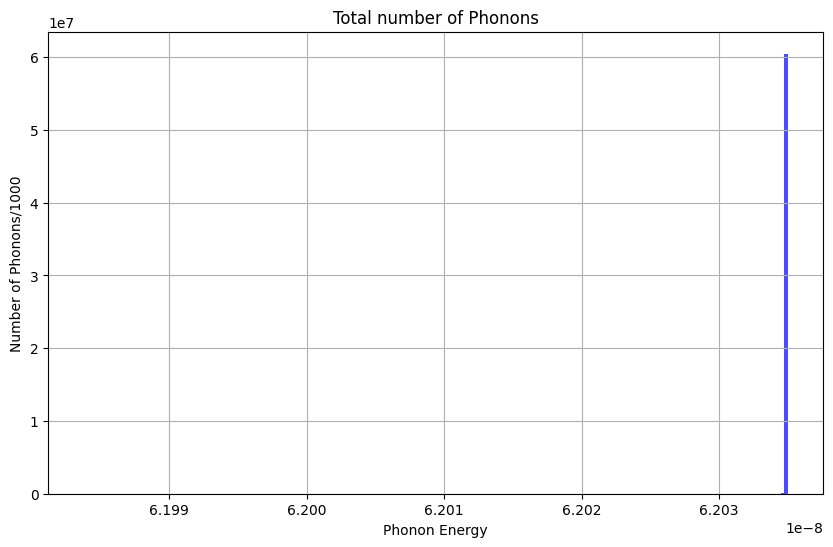

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(df['totalPhonons'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Phonons')
plt.xlabel('Phonon Number/1000')
plt.ylabel('Frequency')
plt.grid()
#plt.savefig("CEvNS_phonon_number.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2['StartEnergy'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Phonons')
plt.xlabel('Phonon Energy')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_phonon_energy.pdf")
plt.show()


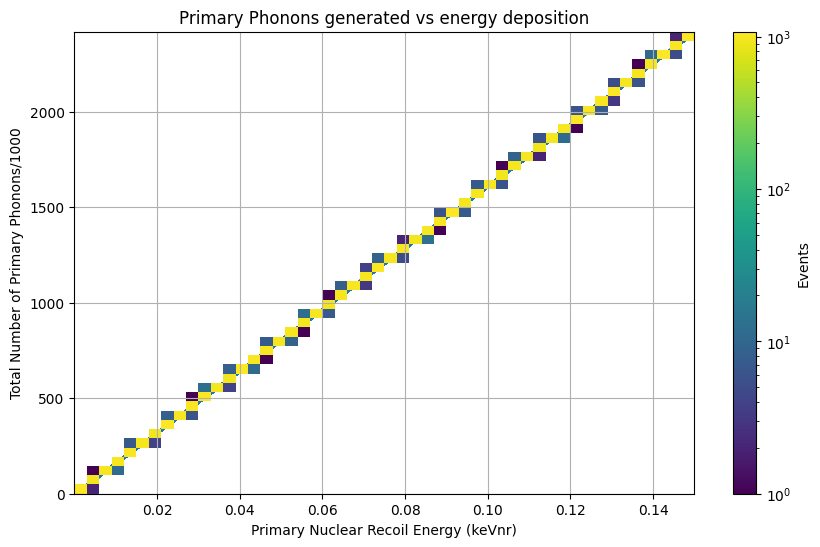

In [5]:

heatmap, xedges, yedges = np.histogram2d(df['PrimaryEnergy'], df['totalPhonons'], bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(df['PrimaryEnergy'], df['totalPhonons'], alpha=0.5, s=1)
plt.title('Primary Phonons generated vs energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Total Number of Primary Phonons/1000')
plt.grid()
#plt.savefig("CEvNS_phonons_vs_nredep.pdf")
plt.show()

In [9]:
from math import *
df2["momentum_mag"] = df2["StartMomX"]**2 + df2["StartMomY"]**2 + df2["StartMomZ"]**2
df2["mom_dir_x"] = df2["StartMomX"]/df2["momentum_mag"]**(1/2)
df2["mom_dir_y"] = df2["StartMomY"]/df2["momentum_mag"]**(1/2)
df2["mom_dir_z"] = df2["StartMomZ"]/df2["momentum_mag"]**(1/2)

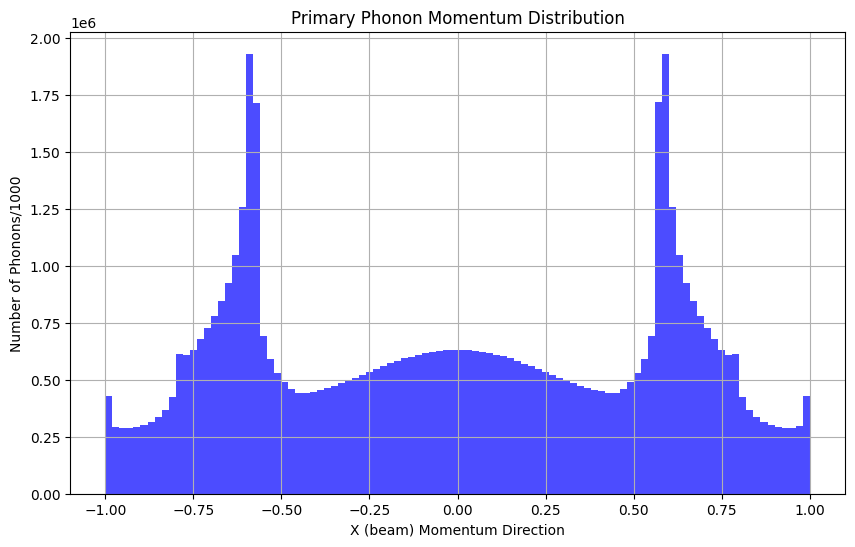

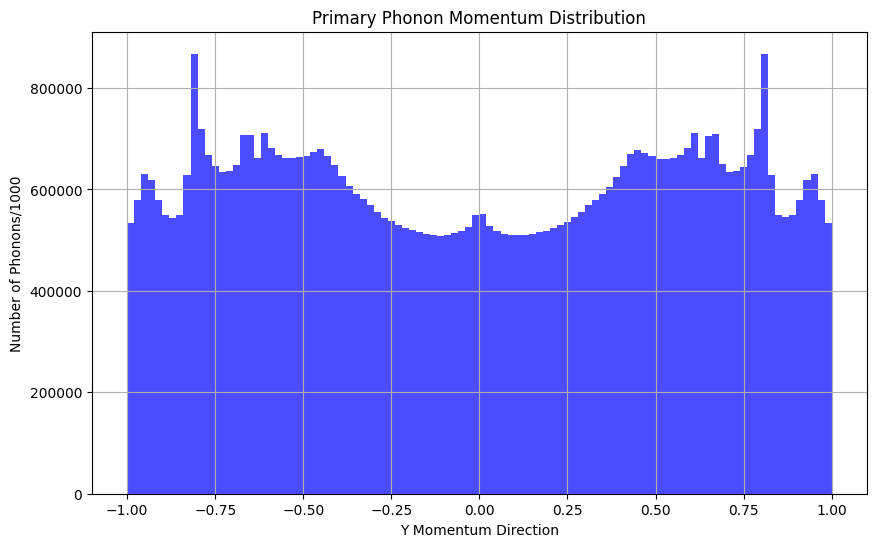

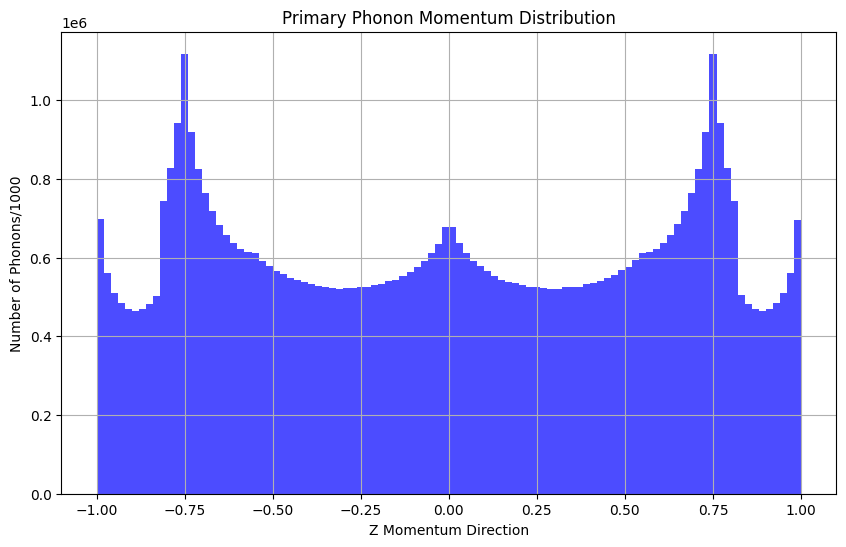

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(df2['mom_dir_x'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('X (beam) Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_primary_phonon_momentumdirx.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2['mom_dir_y'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Y Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_primary_phonon_momentumdiry.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2['mom_dir_z'], bins=100, color='blue', alpha=0.7)
plt.title('Primary Phonon Momentum Distribution')
plt.xlabel('Z Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_primary_phonon_momentumdirz.pdf")
plt.show()


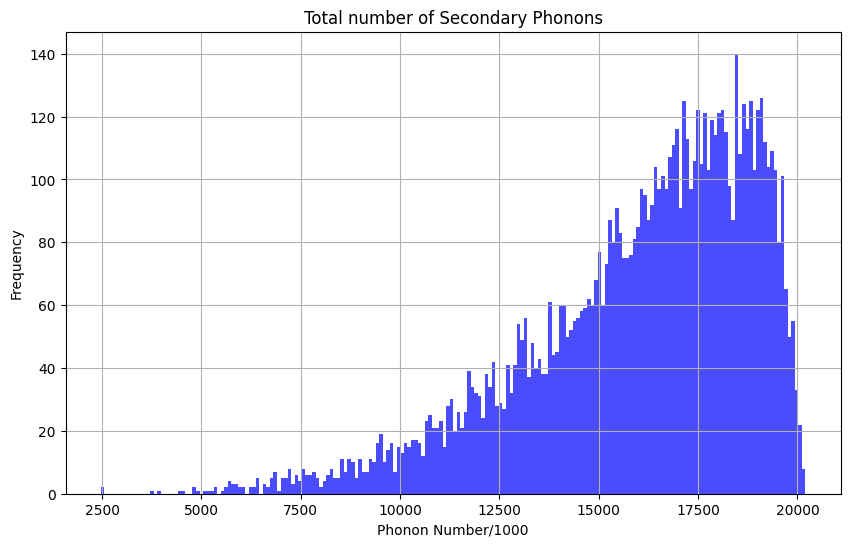

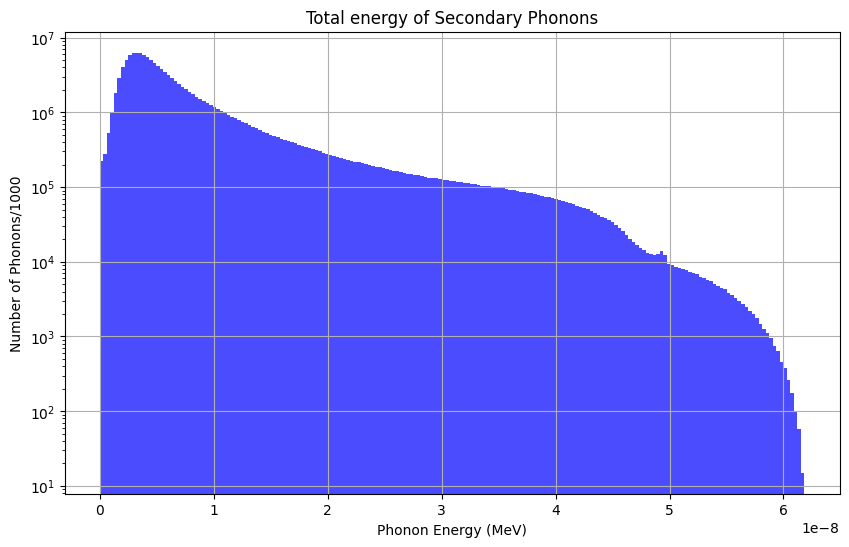

In [19]:
file_ch = uproot.open("/N/project/phonon/PHONON_Bkgnds/job_submission/multisim/7149431/sum_cevns_mono.root")
tree_ch = file_ch["Primary"]
tree2_ch = file_ch["PhononTracks"]

df_ch = tree_ch.arrays(library="pd")
df2_ch = tree2_ch.arrays(library="pd")

plt.figure(figsize=(10, 6))
plt.hist(df_ch['totalPhonons'], bins=200, color='blue', alpha=0.7)
plt.title('Total number of Secondary Phonons')
plt.xlabel('Phonon Number/1000')
plt.ylabel('Frequency')
plt.grid()
plt.savefig("CEvNS_fullsecondary_phonon_number.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2_ch['StartEnergy'], bins=200, color='blue', alpha=0.7)
plt.title('Total energy of Secondary Phonons')
plt.xlabel('Phonon Energy (MeV)')
plt.ylabel('Number of Phonons/1000')
plt.yscale('log')
plt.grid()
plt.savefig("CEvNS_fullsecondary_phonon_energy.pdf")
plt.show()

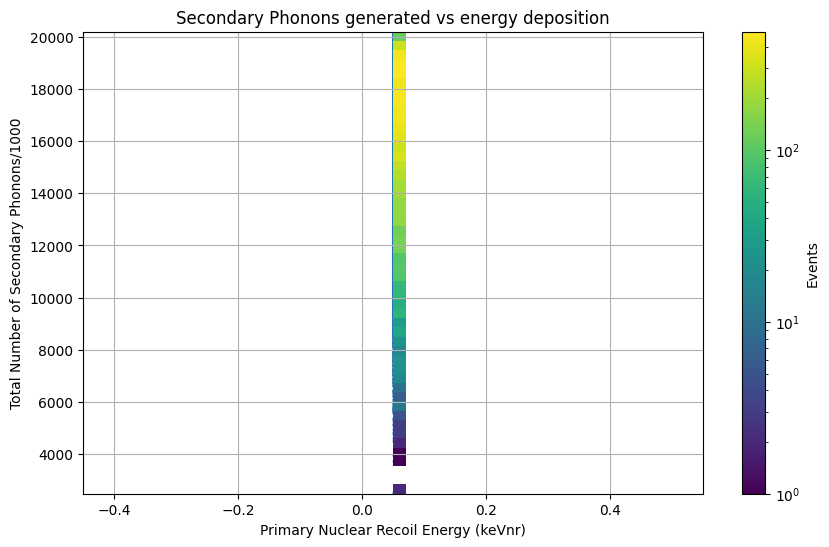

In [20]:
heatmap, xedges, yedges = np.histogram2d(df_ch['PrimaryEnergy'], df_ch['totalPhonons'], bins=50)
#heatmap = heatmap / heatmap.sum()
#heatmap = heatmap / 5000000.0
heatmap = np.ma.masked_where(heatmap == 0, heatmap) 

plt.figure(figsize=(10, 6))
plt.scatter(df_ch['PrimaryEnergy'], df_ch['totalPhonons'], alpha=0.5, s=1)
plt.title('Secondary Phonons generated vs energy deposition')
plt.pcolormesh(xedges,yedges, heatmap.T, norm=LogNorm(), cmap="viridis")
plt.colorbar(label="Events")
plt.xlabel('Primary Nuclear Recoil Energy (keVnr)')
plt.ylabel('Total Number of Secondary Phonons/1000')
plt.grid()
plt.savefig("CEvNS_fullsecondary_phonons_vs_nredep.pdf")
plt.show()

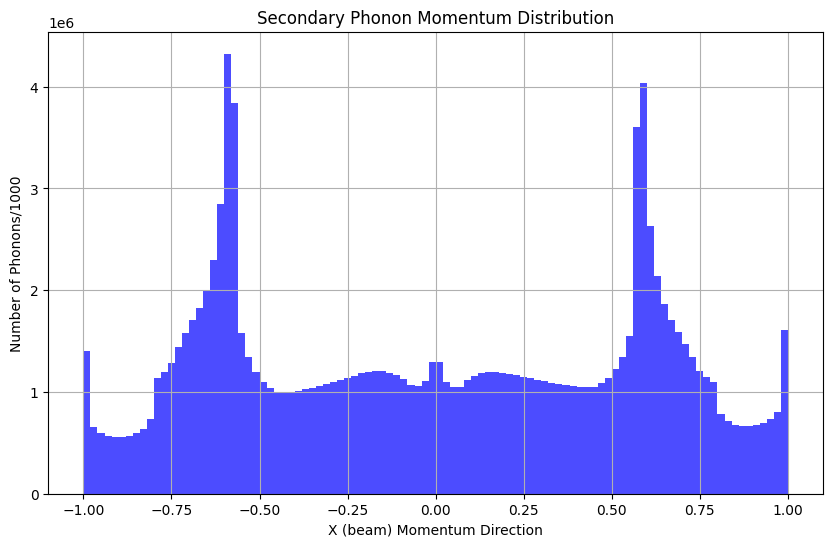

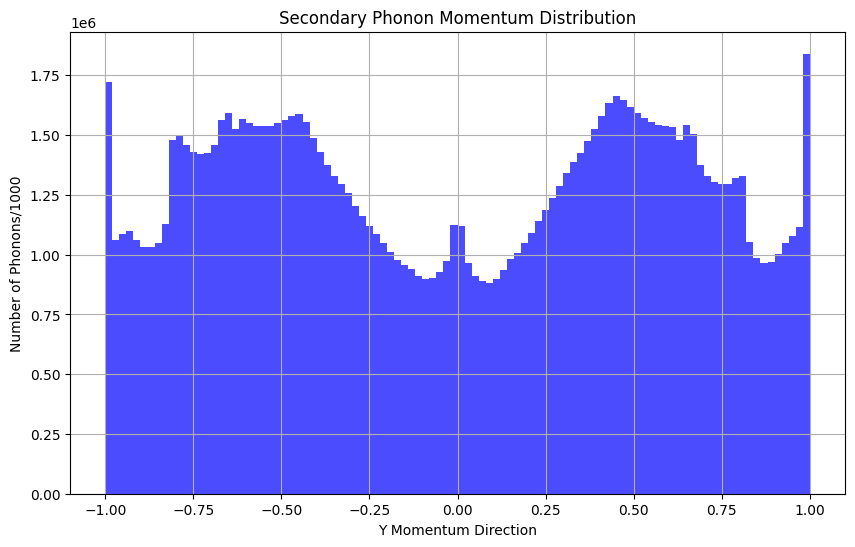

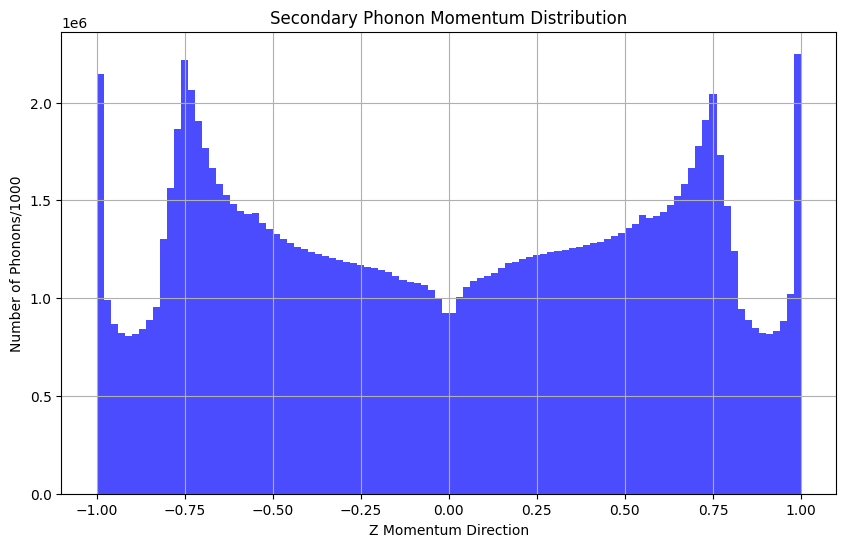

In [22]:
df2_ch["momentum_mag"] = df2_ch["StartMomX"]**2 + df2_ch["StartMomY"]**2 + df2_ch["StartMomZ"]**2
df2_ch["mom_dir_x"] = df2_ch["StartMomX"]/(df2_ch["momentum_mag"]**(1/2))
df2_ch["mom_dir_y"] = df2_ch["StartMomY"]/(df2_ch["momentum_mag"]**(1/2))
df2_ch["mom_dir_z"] = df2_ch["StartMomZ"]/(df2_ch["momentum_mag"]**(1/2))

plt.figure(figsize=(10, 6))
plt.hist(df2_ch['mom_dir_x'], bins=100, color='blue', alpha=0.7)
plt.title('Secondary Phonon Momentum Distribution')
plt.xlabel('X (beam) Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_fullsecondary_phonon_momentumdirx.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2_ch['mom_dir_y'], bins=100, color='blue', alpha=0.7)
plt.title('Secondary Phonon Momentum Distribution')
plt.xlabel('Y Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_fullsecondary_phonon_momentumdiry.pdf")
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df2_ch['mom_dir_z'], bins=100, color='blue', alpha=0.7)
plt.title('Secondary Phonon Momentum Distribution')
plt.xlabel('Z Momentum Direction')
plt.ylabel('Number of Phonons/1000')
plt.grid()
plt.savefig("CEvNS_fullsecondary_phonon_momentumdirz.pdf")
plt.show()